In [1]:
"""
SpaCross Benchmarking Framework -- BC_TNBC_ST (Juno HPC)
==========================================================
Runs SpaCross on all 94 Triple-Negative Breast Cancer ST slices and
saves results in the team-standard parquet format.
 
Dataset citation:
    Wang X, Venet D, Lifrange F et al. Spatial transcriptomics reveals
    substantial heterogeneity in triple-negative breast cancer with
    potential clinical implications. Nat Commun 15, 10232 (2024).
 
Sample IDs: TNBC1-16, TNBC19-96  (94 slices, numbers 17 & 18 skipped)
 
Ground-truth annotations (up to 15 tissue types):
    Acellular stroma / Fat tissue / Heterologous elements /
    High TIL stroma / In situ / Lactiferous duct /
    Low TIL stroma / Lymphocyte / Lymphoid nodule /
    Necrosis / Nerve / Stroma cell / Tumor / Tumor region / Vessels
 
Key difference from DLPFC/HER2 scripts:
  - 94 slices (not 8-12)  -> long runtime, log progress frequently
  - Up to 15 classes      -> cluster count determined per-slice from actual labels
  - Unknown slice sizes   -> graceful skip on OOM / errors, continue with rest
"""

'\nSpaCross Benchmarking Framework -- BC_TNBC_ST (Juno HPC)\n==========================================================\nRuns SpaCross on all 94 Triple-Negative Breast Cancer ST slices and\nsaves results in the team-standard parquet format.\n \nDataset citation:\n    Wang X, Venet D, Lifrange F et al. Spatial transcriptomics reveals\n    substantial heterogeneity in triple-negative breast cancer with\n    potential clinical implications. Nat Commun 15, 10232 (2024).\n \nSample IDs: TNBC1-16, TNBC19-96  (94 slices, numbers 17 & 18 skipped)\n \nGround-truth annotations (up to 15 tissue types):\n    Acellular stroma / Fat tissue / Heterologous elements /\n    High TIL stroma / In situ / Lactiferous duct /\n    Low TIL stroma / Lymphocyte / Lymphoid nodule /\n    Necrosis / Nerve / Stroma cell / Tumor / Tumor region / Vessels\n \nKey difference from DLPFC/HER2 scripts:\n  - 94 slices (not 8-12)  -> long runtime, log progress frequently\n  - Up to 15 classes      -> cluster count determined

# Imports

In [ ]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")
 
import os
import sys
import time
import logging
from pathlib import Path
 
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

import torch
import torch_geometric
import torch_scatter
import torch_sparse
import torch_cluster

# USER CONFIGURATION -- edit these to match your environment

In [ ]:
# =============================================================================
# USER CONFIGURATION -- edit these to match your environment
# =============================================================================

SPACROSS_ROOT = Path("/work/dal875013/projects/mocha/methods/spacross/SpaCross")
DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data")
OUTPUT_DIR = Path("/home/dal875013/work/projects/mocha/results/Spacross/bc_tnbc_spacross")
CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"
 
# TNBC1-16 and TNBC19-96 (17, 18 skipped per README)
ALL_TNBC_SAMPLES = (
    [f"TNBC{i}" for i in range(1, 17)] +
    [f"TNBC{i}" for i in range(19, 97)]
)
 
# SAMPLES_TO_RUN:
#   None or "all" -> run all 94
#   list -> subset  (for testing, try ["TNBC1"] first!)
#   string -> single slice
SAMPLES_TO_RUN = None
 
METHOD_NAME = "SpaCross"
 
# "mclust" (needs R + rpy2, adds ~10-20s per slice) or "kmeans" (faster)
CLUST_METHOD = "mclust"
 
NUM_RUNS = 1
 
# Ground-truth column name in adata.obs
GT_LABEL_COL = "z"
 
# Spatial coordinates key in adata.obsm
SPATIAL_KEY = "S"
 
# Maximum number of slices to skip before aborting entirely.
# Protects against e.g. mis-path where every slice fails.
MAX_CONSECUTIVE_FAILURES = 5
 
# Save intermediate parquet every N slices (in case of crash / timeout,
# you don't lose all progress). Set to 0 to disable intermediate saves.
SAVE_EVERY_N = 10
 
 
# =============================================================================
# GPU / device
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] VRAM: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU (slow)")
    return dev
 
 
# =============================================================================
# Logging
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")
 
 
# =============================================================================
# Sample selector
# =============================================================================
def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_TNBC_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

# Data loading

In [4]:
# =============================================================================
# Data loading
# =============================================================================
def load_tnbc_sample(config: dict, sample_id: str, tools_mod):
    """Load one TNBC slice, return (adata, edge_index, num_clusters_this_slice)."""
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")
 
    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()
 
    logging.info(f"  [DIAG] n_obs={adata.n_obs}, n_vars={adata.n_vars}")
 
    # ---- Ground-truth label column ----
    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )
    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)
    gt = adata.obs["layer_guess"]
    n_labeled = gt.notna().sum()
    uniq = sorted([str(x) for x in gt.dropna().unique()])
    n_classes = len(uniq)
    logging.info(
        f"  [DIAG] GT '{GT_LABEL_COL}': {n_labeled}/{adata.n_obs} labeled, "
        f"{n_classes} classes: {uniq}"
    )
    if n_labeled == 0:
        raise ValueError(f"Slice {sample_id} has NO labeled spots")
    if n_classes < 2:
        raise ValueError(
            f"Slice {sample_id} has only {n_classes} class "
            f"-- nothing to cluster against"
        )
 
    # ---- Alias spatial coords ----
    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
        else:
            raise KeyError(
                f"No spatial coords. Available obsm: {list(adata.obsm.keys())}"
            )
 
    # ---- k-NN graph ----
    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)
 
    # ---- Preprocess ----
    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()
 
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
 
    sc.pp.normalize_total(adata, target_sum=1e6)
    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata, flavor="seurat_v3", layer="count", n_top_genes=top_g,
    )
    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)
 
    # ---- PCA ----
    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs, random_state=42
    ).fit_transform(adata.X)
 
    logging.info(
        f"  [DIAG] After preproc: n_vars={adata.n_vars}, "
        f"X_pca={adata.obsm['X_pca'].shape}, num_clusters={n_classes}"
    )
 
    return adata, edge_index, n_classes

# Train one slice

In [5]:
# =============================================================================
# Train one slice
# =============================================================================
def train_one_slice(
    sample_id: str,
    adata,
    edge_index,
    num_clusters: int,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    logging.info(
        f"  [TRAIN] SpaCross | slice={sample_id} | k={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )
    t0 = time.time()
 
    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )
    net.trian()
    enc_rep, recon = net.process()
 
    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon
 
    pred_labels = tools_mod.clustering(
        z=enc_rep, n_clust=num_clusters, num_seed=1, method=clust_method,
    )
    adata.obs[clust_method] = pred_labels
 
    elapsed = time.time() - t0
 
    # Metrics (on labeled spots only)
    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]
    ARI, ACC, DIS = tools_mod.get_metrics(sub_adata, "layer_guess", clust_method)
    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)
 
    gpu_name = (
        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    )
 
    metrics = {
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "NMI": float(NMI),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
        "dataset": "BC_TNBC_ST",
    }
    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s"
    )
 
    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })
 
    return metrics, pred_df

# =============================================================================
# Save parquet results
# =============================================================================
def save_results(all_metrics, all_predictions, output_dir, tag=""):
    if not all_metrics:
        return
    performance = pd.DataFrame(all_metrics)
    predictions = pd.concat(all_predictions, ignore_index=True)
 
    perf_lead = ["method", "sample", "run_seed",
                 "ARI", "NMI", "ACC", "DIS",
                 "running_time_sec", "gpu_model"]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]
    pred_lead = ["method", "sample", "run_seed", "spot_id",
                 "true_label", "pred_label"]
    predictions = predictions[pred_lead]
 
    pred_path = output_dir / f"predictions{tag}.parquet"
    perf_path = output_dir / f"performance{tag}.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)
    logging.info(
        f"  [SAVE] {pred_path.name}: {len(predictions):,} rows  |  "
        f"{perf_path.name}: {len(performance):,} rows"
    )

# Main benchmark loop

In [ ]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)
 
    logging.info("=" * 72)
    logging.info("SpaCross BC_TNBC_ST Benchmarking Framework (Juno)")
    logging.info("=" * 72)
 
    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(f"SPACROSS_ROOT not found: {SPACROSS_ROOT}")
    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS  # noqa: N814
 
    device = get_device()
 
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")
    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH}")
    logging.info(f"[ENV]   R_HOME        = {os.environ.get('R_HOME')}")
 
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    logging.info(f"[CONFIG] {config}")
 
    samples = resolve_samples(SAMPLES_TO_RUN)
    logging.info(f"[SAMPLES] {len(samples)} slice(s) to process")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  num_runs={NUM_RUNS}"
    )
 
    all_metrics = []
    all_predictions = []
    failed = []
    consecutive_failures = 0
    t_start = time.time()
 
    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(
            f"[{i}/{len(samples)}] Slice {sample_id}  "
            f"(elapsed: {(time.time() - t_start):.1f}s, "
            f"failed so far: {len(failed)})"
        )
        logging.info("-" * 72)
 
        try:
            adata, edge_index, num_clusters = load_tnbc_sample(
                config, sample_id, TOOLS
            )
 
            for run in range(NUM_RUNS):
                if NUM_RUNS > 1:
                    logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()
 
                metrics, pred_df = train_one_slice(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    num_clusters=num_clusters,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )
                all_metrics.append(metrics)
                all_predictions.append(pred_df)
 
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
 
            consecutive_failures = 0
 
            # Intermediate save
            if SAVE_EVERY_N and i % SAVE_EVERY_N == 0:
                logging.info(f"  [INTERMEDIATE SAVE at slice {i}/{len(samples)}]")
                save_results(all_metrics, all_predictions, OUTPUT_DIR)
 
        except Exception as e:
            logging.exception(f"[FAILED] Slice {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})
            consecutive_failures += 1
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
 
            if consecutive_failures >= MAX_CONSECUTIVE_FAILURES:
                logging.error(
                    f"Aborting: {consecutive_failures} consecutive failures. "
                    f"Something is systemically wrong (bad path? bad env?)."
                )
                break
            continue
 
    # Final save
    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return
 
    save_results(all_metrics, all_predictions, OUTPUT_DIR)
 
    performance = pd.DataFrame(all_metrics)
    total_time = time.time() - t_start
 
    logging.info("")
    logging.info("=" * 72)
    logging.info("FINAL RESULTS")
    logging.info("=" * 72)
    logging.info(f"Total slices processed: {len(performance)} / {len(samples)}")
    logging.info(f"Failed slices: {len(failed)}")
    logging.info(f"Total wall time: {total_time:.1f}s ({total_time/60:.1f} min)")
    logging.info(
        f"Mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )
    logging.info(
        f"ARI median: {performance['ARI'].median():.4f}  "
        f"min: {performance['ARI'].min():.4f}  "
        f"max: {performance['ARI'].max():.4f}"
    )
 
    if failed:
        logging.warning(f"\nFailed slices ({len(failed)}):")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error'][:100]}")
 
    logging.info("\nBenchmarking complete.")
 
 
if __name__ == "__main__":
    run_benchmark()

2026-04-24 23:35:00,511 [INFO] Log file: /work/dal875013/projects/mocha/results/bc_tnbc_spacross/benchmark.log
2026-04-24 23:35:00,512 [INFO] ========================================================================
2026-04-24 23:35:00,512 [INFO] SpaCross BC_TNBC_ST Benchmarking Framework (Juno)
2026-04-24 23:35:00,513 [INFO] ========================================================================
2026-04-24 23:35:00,893 [INFO] cffi mode is CFFI_MODE.ANY
2026-04-24 23:35:01,070 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-04-24 23:35:02,882 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:
2026-04-24 23:35:02,883 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib
2026-04-24 23:35:02,912 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-04-24 23:35:03,835 [INFO] R is already initialized. No need to initialize.
2026-04-24 23:35:06,061 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-04-24 23:35:06,102 [IN

Epoch 299 total loss=1.507 recon loss=0.911 mean loss=0.427 tri loss=1.387: 100%|██████████| 300/300 [00:08<00:00, 33.62it/s]


[DEBUG mclust] emb shape = (922, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 23:35:20,846 [INFO]   [METRICS] ARI=0.1062  NMI=0.1769  ACC=0.1845  DIS=0.0606  time=12.4s
2026-04-24 23:35:20,857 [INFO] 
2026-04-24 23:35:20,861 [INFO] ------------------------------------------------------------------------
2026-04-24 23:35:20,861 [INFO] [2/94] Slice TNBC2  (elapsed: 14.7s, failed so far: 0)
2026-04-24 23:35:20,862 [INFO] ------------------------------------------------------------------------
2026-04-24 23:35:20,864 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data/SCE_TNBC2.h5ad
2026-04-24 23:35:21,227 [INFO]   [DIAG] n_obs=1071, n_vars=29149
2026-04-24 23:35:21,229 [INFO]   [DIAG] GT 'z': 1071/1071 labeled, 8 classes: ['Acellular stroma', 'Fat tissue', 'Low TIL stroma', 'Lymphocyte', 'Necrosis', 'Stroma cell', 'Tumor', 'Vessels']
2026-04-24 23:35:22,965 [INFO]   [DIAG] After preproc: n_vars

Epoch 299 total loss=1.580 recon loss=1.048 mean loss=0.423 tri loss=1.374: 100%|██████████| 300/300 [00:08<00:00, 35.36it/s]


[DEBUG mclust] emb shape = (1071, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 23:35:34,631 [INFO]   [METRICS] ARI=0.2540  NMI=0.3713  ACC=0.3896  DIS=0.0607  time=11.3s
2026-04-24 23:35:34,644 [INFO] 
2026-04-24 23:35:34,646 [INFO] ------------------------------------------------------------------------
2026-04-24 23:35:34,647 [INFO] [3/94] Slice TNBC3  (elapsed: 28.5s, failed so far: 0)
2026-04-24 23:35:34,648 [INFO] ------------------------------------------------------------------------
2026-04-24 23:35:34,649 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data/SCE_TNBC3.h5ad
2026-04-24 23:35:35,038 [INFO]   [DIAG] n_obs=434, n_vars=26534
2026-04-24 23:35:35,043 [INFO]   [DIAG] GT 'z': 434/434 labeled, 5 classes: ['Acellular stroma', 'High TIL stroma', 'Lymphocyte', 'Stroma cell', 'Tumor']
2026-04-24 23:35:35,764 [INFO]   [DIAG] After preproc: n_vars=2000, X_pca=(434, 200), num_clusters=

...

[DEBUG mclust] emb shape = (1148, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 23:49:16,659 [INFO]   [METRICS] ARI=-0.0140  NMI=0.0320  ACC=0.0321  DIS=0.0573  time=6.1s
2026-04-24 23:49:16,665 [INFO] 
2026-04-24 23:49:16,666 [INFO] ------------------------------------------------------------------------
2026-04-24 23:49:16,666 [INFO] [93/94] Slice TNBC95  (elapsed: 850.5s, failed so far: 0)
2026-04-24 23:49:16,667 [INFO] ------------------------------------------------------------------------
2026-04-24 23:49:16,668 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data/SCE_TNBC95.h5ad
2026-04-24 23:49:17,019 [INFO]   [DIAG] n_obs=1453, n_vars=29220
2026-04-24 23:49:17,020 [INFO]   [DIAG] GT 'z': 1453/1453 labeled, 9 classes: ['Acellular stroma', 'Fat tissue', 'Heterologous elements', 'High TIL stroma', 'Lactiferous duct', 'Low TIL stroma', 'Stroma cell', 'Tumor', 'Vessels']
2026-04-24 23:49:1

Epoch 299 total loss=1.570 recon loss=1.038 mean loss=0.418 tri loss=1.369: 100%|██████████| 300/300 [00:04<00:00, 62.60it/s]


[DEBUG mclust] emb shape = (1453, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 23:49:25,348 [INFO]   [METRICS] ARI=0.0341  NMI=0.0970  ACC=0.1130  DIS=0.0568  time=7.3s
2026-04-24 23:49:25,352 [INFO] 
2026-04-24 23:49:25,352 [INFO] ------------------------------------------------------------------------
2026-04-24 23:49:25,353 [INFO] [94/94] Slice TNBC96  (elapsed: 859.2s, failed so far: 0)
2026-04-24 23:49:25,354 [INFO] ------------------------------------------------------------------------
2026-04-24 23:49:25,354 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data/SCE_TNBC96.h5ad
2026-04-24 23:49:25,737 [INFO]   [DIAG] n_obs=1222, n_vars=27912
2026-04-24 23:49:25,739 [INFO]   [DIAG] GT 'z': 1222/1222 labeled, 6 classes: ['High TIL stroma', 'Lactiferous duct', 'Low TIL stroma', 'Necrosis', 'Tumor', 'Vessels']
2026-04-24 23:49:26,611 [INFO]   [DIAG] After preproc: n_vars=2000, X_pca=(1222, 

Epoch 299 total loss=1.516 recon loss=0.927 mean loss=0.446 tri loss=1.377: 100%|██████████| 300/300 [00:04<00:00, 64.32it/s]


[DEBUG mclust] emb shape = (1222, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-04-24 23:49:32,943 [INFO]   [METRICS] ARI=0.2542  NMI=0.3544  ACC=0.3803  DIS=0.0622  time=6.2s
2026-04-24 23:49:33,025 [INFO]   [SAVE] predictions.parquet: 86,806 rows  |  performance.parquet: 94 rows
2026-04-24 23:49:33,027 [INFO] 
2026-04-24 23:49:33,028 [INFO] ========================================================================
2026-04-24 23:49:33,029 [INFO] FINAL RESULTS
2026-04-24 23:49:33,029 [INFO] ========================================================================
2026-04-24 23:49:33,030 [INFO] Total slices processed: 94 / 94
2026-04-24 23:49:33,031 [INFO] Failed slices: 0
2026-04-24 23:49:33,031 [INFO] Total wall time: 866.9s (14.4 min)
2026-04-24 23:49:33,032 [INFO] Mean ARI: 0.0934  NMI: 0.1775  ACC: 0.1830  DIS: 0.0657
2026-04-24 23:49:33,033 [INFO] ARI median: 0.0649  min: -0.1133  max: 0.4043
2026-04-24 23:49:33,

# prediction results visulization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


SAMPLE_ID = TNBC90
n spots in adata      : 1023
n predictions matched : 1023


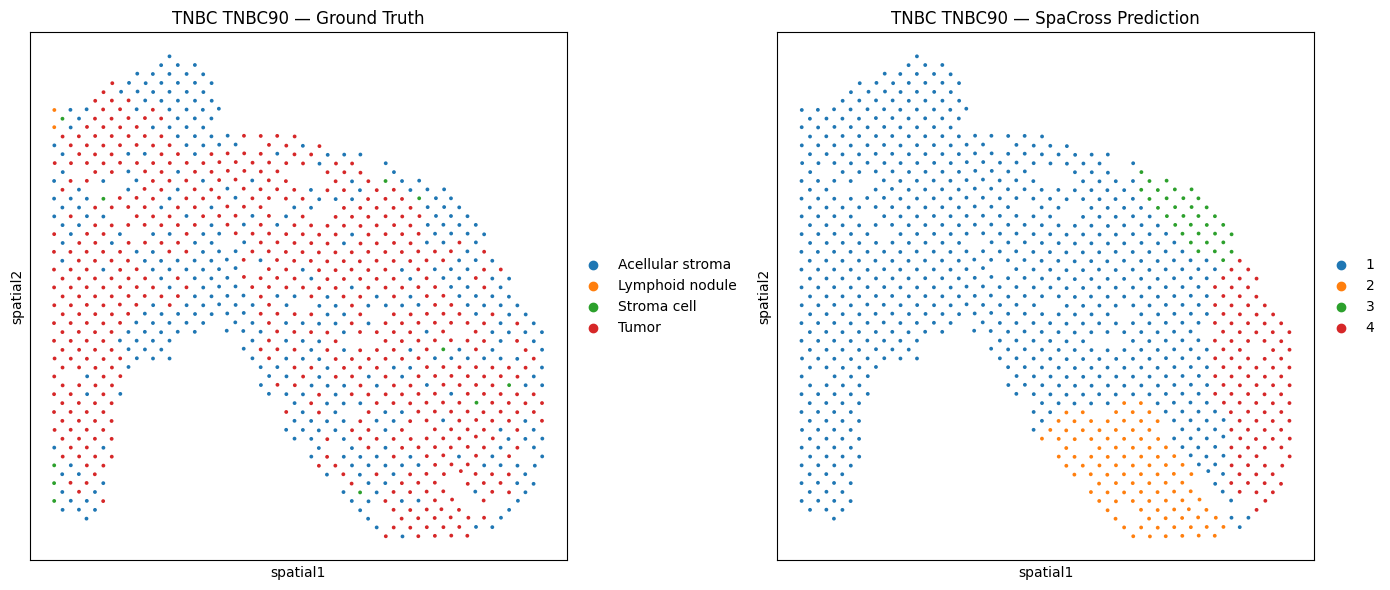

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path("/groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data")
OUTPUT_DIR = Path("/home/dal875013/work/projects/mocha/results/Spacross/bc_tnbc_spacross")

SAMPLE_ID = "TNBC90"   # e.g. "TNBC1", "TNBC50", "TNBC96"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    available = sorted(predictions["sample"].unique())
    raise ValueError(
        f"No predictions found for sample '{SAMPLE_ID}'. "
        f"Available samples ({len(available)}): {available[:10]}..."
    )

pred_slice = pred_slice.set_index("spot_id")

h5ad_path = DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad"
adata = sc.read_h5ad(h5ad_path)
adata.var_names_make_unique()

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates. obsm keys = {list(adata.obsm.keys())}")

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

# 如果有 ground truth 就画两张，没有就只画 prediction
has_gt = adata.obs["true_label"].notna().any()

if has_gt:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sc.pl.embedding(adata, basis="spatial", color="true_label",
                    ax=axes[0], show=False,
                    title=f"TNBC {SAMPLE_ID} — Ground Truth", s=30)
    sc.pl.embedding(adata, basis="spatial", color="pred_label",
                    ax=axes[1], show=False,
                    title=f"TNBC {SAMPLE_ID} — SpaCross Prediction", s=30)
    axes[0].invert_yaxis()
    axes[1].invert_yaxis()
else:
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    sc.pl.embedding(adata, basis="spatial", color="pred_label",
                    ax=ax, show=False,
                    title=f"TNBC {SAMPLE_ID} — SpaCross Prediction (no GT)", s=30)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("/home/dal875013/work/projects/mocha/results/Spacross/bc_tnbc_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
 
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "sample", "run_seed", "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model"
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary = performance[["ARI", "NMI", "ACC", "DIS", "running_time_sec"]].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All SpaCross results =====


,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,TNBC1,0,0.106200,0.176850,0.184540,0.060601,8,922,922,7.82,mclust,NVIDIA A30
1,TNBC10,0,0.023514,0.138687,0.151322,0.069763,7,674,674,4.86,mclust,NVIDIA A30
2,TNBC11,0,0.026932,0.073256,0.089834,0.059543,7,1049,1049,5.64,mclust,NVIDIA A30
3,TNBC12,0,0.051318,0.161857,0.174548,0.070009,8,816,816,5.39,mclust,NVIDIA A30
4,TNBC13,0,0.105072,0.201288,0.228668,0.063087,7,1021,1021,5.96,mclust,NVIDIA A30
...,...,...,...,...,...,...,...,...,...,...,...,...
89,TNBC92,0,0.027384,0.086859,0.087106,0.076350,5,779,779,4.76,mclust,NVIDIA A30
90,TNBC93,0,-0.113292,0.050052,0.052174,0.060311,3,517,517,4.11,mclust,NVIDIA A30
91,TNBC94,0,-0.014032,0.032049,0.032133,0.057313,4,1148,1148,5.78,mclust,NVIDIA A30
92,TNBC95,0,0.034122,0.096969,0.112960,0.056845,9,1453,1453,7.03,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,94.000000,94.000000,94.000000,94.000000,94.000000
mean,0.093359,0.177488,0.182998,0.065689,5.567234
std,0.095452,0.112686,0.114088,0.009743,1.197467
min,-0.113292,0.019332,0.019346,0.047384,3.610000
25%,0.026788,0.091988,0.093061,0.059162,4.645000
50%,0.064926,0.156534,0.162864,0.064321,5.345000
75%,0.121193,0.235599,0.246817,0.071447,6.277500
max,0.404296,0.490455,0.492651,0.090531,8.690000



===== Mean metrics =====
Mean ARI: 0.0934
Mean NMI: 0.1775
Mean ACC: 0.1830
Mean DIS: 0.0657

===== Best / worst ARI =====
Best ARI : TNBC74  ARI=0.4043
Worst ARI: TNBC93  ARI=-0.1133


# actual layer in ground truth checking

In [1]:
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data")

ALL_BC_TNBC_SAMPLES = (
    [f"TNBC{i}" for i in range(1, 17)] +
    [f"TNBC{i}" for i in range(19, 97)]
)

results = []

for sample_id in ALL_BC_TNBC_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}: {path}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}; obs columns = {list(adata.obs.columns)}")
        continue

    labels_all = adata.obs["z"]

    # remove NaN labels
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

df = pd.DataFrame(results).sort_values(["n_classes", "sample"])

print("===== BC_TNBC_ST: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

===== BC_TNBC_ST: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
22,TNBC25,3,"[Acellular stroma, Stroma cell, Tumor]",1273,1273,0
65,TNBC68,3,"[Acellular stroma, Stroma cell, Tumor]",538,538,0
90,TNBC93,3,"[Acellular stroma, Lymphocyte, Tumor]",517,517,0
20,TNBC23,4,"[Acellular stroma, Necrosis, Stroma cell, Tumor]",744,744,0
23,TNBC26,4,"[Acellular stroma, Necrosis, Stroma cell, Tumor]",131,131,0
...,...,...,...,...,...,...
4,TNBC5,10,"[Acellular stroma, Fat tissue, High TIL stroma...",1438,1438,0
77,TNBC80,10,"[Acellular stroma, Fat tissue, High TIL stroma...",737,737,0
83,TNBC86,10,"[Acellular stroma, Fat tissue, High TIL stroma...",672,672,0
79,TNBC82,11,"[Acellular stroma, Fat tissue, High TIL stroma...",1193,1193,0



===== Summary =====
n_classes
3      3
4      8
5     15
6     22
7     21
8     15
9      5
10     3
11     2
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'TNBC25': 3, 'TNBC68': 3, 'TNBC93': 3, 'TNBC23': 4, 'TNBC26': 4, 'TNBC34': 4, 'TNBC52': 4, 'TNBC69': 4, 'TNBC79': 4, 'TNBC90': 4, 'TNBC94': 4, 'TNBC19': 5, 'TNBC21': 5, 'TNBC24': 5, 'TNBC27': 5, 'TNBC3': 5, 'TNBC36': 5, 'TNBC49': 5, 'TNBC54': 5, 'TNBC70': 5, 'TNBC74': 5, 'TNBC76': 5, 'TNBC8': 5, 'TNBC84': 5, 'TNBC88': 5, 'TNBC92': 5, 'TNBC14': 6, 'TNBC28': 6, 'TNBC31': 6, 'TNBC35': 6, 'TNBC37': 6, 'TNBC39': 6, 'TNBC41': 6, 'TNBC42': 6, 'TNBC43': 6, 'TNBC46': 6, 'TNBC48': 6, 'TNBC55': 6, 'TNBC56': 6, 'TNBC57': 6, 'TNBC58': 6, 'TNBC59': 6, 'TNBC63': 6, 'TNBC65': 6, 'TNBC66': 6, 'TNBC81': 6, 'TNBC83': 6, 'TNBC96': 6, 'TNBC10': 7, 'TNBC11': 7, 'TNBC13': 7, 'TNBC15': 7, 'TNBC20': 7, 'TNBC29': 7, 'TNBC32': 7, 'TNBC38': 7, 'TNBC4': 7, 'TNBC40': 7, 'TNBC44': 7, 